# Set up the environment


In [ ]:
!pip install -q torchsummary
!pip install kagglehub -q
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

Device: cuda
GPU: Tesla T4


Improve method
- reduce beta
- increase image size
- increase epoch
- use tanH

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
path = kagglehub.dataset_download("vishalsubbiah/pokemon-images-and-types")
print("Dataset path:", path)

Using Colab cache for faster access to the 'pokemon-images-and-types' dataset.
Dataset path: /kaggle/input/pokemon-images-and-types


In [ ]:
import os

print(os.listdir(path))

['images', 'pokemon.csv']


In [ ]:
from pathlib import Path
import pandas as pd

# Dataset root
DATA_ROOT = Path(path)

# Correct image directory
IMAGE_DIR = DATA_ROOT / "images"

# CSV path
csv_path = DATA_ROOT / "pokemon.csv"

# Sanity checks
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"IMAGE_DIR exists: {IMAGE_DIR.exists()}")
print(f"CSV exists:       {csv_path.exists()}")

# List image files
image_files = list(IMAGE_DIR.glob("*"))

print(f"\nFound {len(image_files)} files in images/")
print(f"Sample filenames: {[f.name for f in image_files[:5]]}")

# Read CSV
df = pd.read_csv(csv_path)

print(f"\nCSV columns: {df.columns.tolist()}")
print(df.head())

print(f"\nTotal rows: {len(df)}")
print(f"Unique Type1: {df['Type1'].nunique()}")

print(f"\nType distribution:\n{df['Type1'].value_counts()}")

DATA_ROOT exists: True
IMAGE_DIR exists: True
CSV exists:       True

Found 809 files in images/
Sample filenames: ['throh.png', 'samurott.png', 'venomoth.png', 'latios.png', 'shinx.png']

CSV columns: ['Name', 'Type1', 'Type2', 'Evolution']
         Name  Type1   Type2   Evolution
0   bulbasaur  Grass  Poison     ivysaur
1     ivysaur  Grass  Poison    venusaur
2    venusaur  Grass  Poison         NaN
3  charmander   Fire     NaN  charmeleon
4  charmeleon   Fire     NaN   charizard

Total rows: 809
Unique Type1: 18

Type distribution:
Type1
Water       114
Normal      105
Grass        78
Bug          72
Fire         53
Psychic      53
Rock         46
Electric     40
Poison       34
Ground       32
Dark         29
Fighting     29
Dragon       27
Ghost        27
Steel        26
Ice          23
Fairy        18
Flying        3
Name: count, dtype: int64


In [ ]:
unique_types = sorted(df['Type1'].unique())
type_to_idx = {t: i for i, t in enumerate(unique_types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
NUM_TYPES = len(type_to_idx)
print(f"Number of types: {NUM_TYPES}")
print(f"Type mapping: {type_to_idx}")

# Build a lookup of all image files by stem (filename without extension), case-insensitive
image_lookup = {}
for f in IMAGE_DIR.glob("*"):
    if f.suffix.lower() in ['.png', '.jpg', '.jpeg']:
        image_lookup[f.stem.lower()] = f

def find_image(name):
    # Try a few common variations to be safe
    variants = [
        name,
        name.lower(),
        name.replace(' ', '_'),
        name.replace(' ', '-'),
        name.replace('♀', 'f').replace('♂', 'm'),
    ]
    for v in variants:
        match = image_lookup.get(v.lower())
        if match:
            return match
    return None

df['image_path'] = df['Name'].apply(find_image)

missing = df[df['image_path'].isna()]
if len(missing) > 0:
    print(f"\n⚠️  {len(missing)} Pokemon in CSV have no matching image:")
    print(missing['Name'].tolist()[:10])

df = df[df['image_path'].notna()].reset_index(drop=True)
print(f"\nPokemon successfully matched: {len(df)}")

Number of types: 18
Type mapping: {'Bug': 0, 'Dark': 1, 'Dragon': 2, 'Electric': 3, 'Fairy': 4, 'Fighting': 5, 'Fire': 6, 'Flying': 7, 'Ghost': 8, 'Grass': 9, 'Ground': 10, 'Ice': 11, 'Normal': 12, 'Poison': 13, 'Psychic': 14, 'Rock': 15, 'Steel': 16, 'Water': 17}

Pokemon successfully matched: 809


In [ ]:
class PokemonDataset(Dataset):
    def __init__(self, df, type_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.type_to_idx = type_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path'])
        # Composite transparent PNGs onto white background
        if img.mode == 'RGBA':
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            img = bg
        else:
            img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)

        type_idx = self.type_to_idx[row['Type1']]
        type_oh = torch.zeros(len(self.type_to_idx))
        type_oh[type_idx] = 1.0
        return img, type_oh, type_idx

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # values in [0, 1] — required for BCE loss + sigmoid output
])

full_ds = PokemonDataset(df, type_to_idx, transform=transform)

val_size = int(0.1 * len(full_ds))
train_size = len(full_ds) - val_size
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 729 | Val: 80


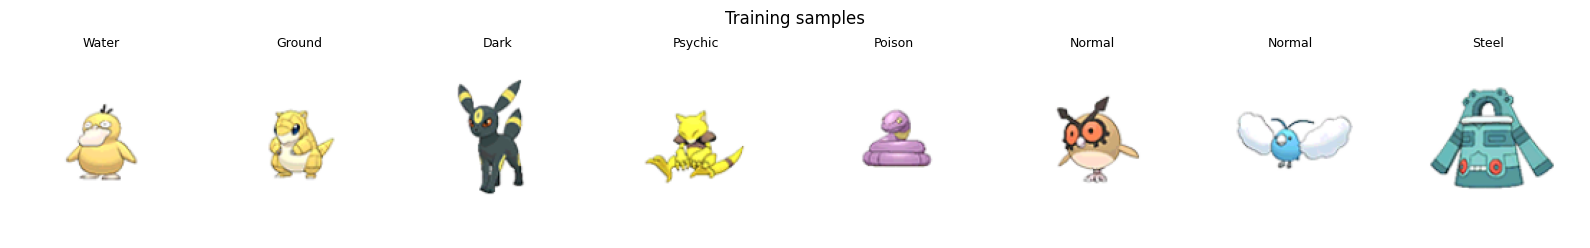

In [ ]:
imgs, types_oh, type_idx = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i in range(8):
    axes[i].imshow(imgs[i].permute(1, 2, 0))
    axes[i].set_title(idx_to_type[type_idx[i].item()], fontsize=9)
    axes[i].axis("off")
plt.suptitle("Training samples")
plt.tight_layout()
plt.show()

In [ ]:
class ConditionalVAE(nn.Module):
    def __init__(self, num_types, latent_dim=128):
        super().__init__()
        self.num_types = num_types
        self.latent_dim = latent_dim

        # Encoder: 128x128x3 -> 4x4x512
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),    # 64x64
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # 32x32
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 8x8
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, stride=2, padding=1), # 4x4
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
        )

        self.flatten_dim = 512 * 4 * 4

        # Conditioning is injected by concatenating type one-hot to flattened features
        self.fc_mu = nn.Linear(self.flatten_dim + num_types, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim + num_types, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim + num_types, self.flatten_dim)

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 32x32
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 64x64
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),     # 128x128
            # nn.Sigmoid(),
            nn.Tanh()
        )

    def encode(self, x, c):
        h = self.encoder(x).flatten(1)
        h = torch.cat([h, c], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        h = self.fc_decode(torch.cat([z, c], dim=1))
        h = h.view(-1, 512, 4, 4)
        return self.decoder(h)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    return recon_loss + beta * kl_loss, recon_loss, kl_loss


# # Sanity check
# model = ConditionalVAE(NUM_TYPES, LATENT_DIM).to(device)

# print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# test_x = torch.randn(2, 3, 128, 128).to(device)

# test_c = torch.zeros(2, NUM_TYPES).to(device)
# test_c[:, 0] = 1

# test_out, test_mu, test_lv = model(test_x, test_c)

# print(f"Forward pass OK | Output: {test_out.shape}")

In [ ]:
def train_one_epoch(model, loader, optimizer, beta):
    model.train()
    total, recon_t, kl_t = 0, 0, 0
    for imgs, types_oh, _ in loader:
        imgs, types_oh = imgs.to(device), types_oh.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(imgs, types_oh)
        loss, r, k = vae_loss(recon, imgs, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
        recon_t += r.item() * imgs.size(0)
        kl_t += k.item() * imgs.size(0)
    n = len(loader.dataset)
    return total/n, recon_t/n, kl_t/n


@torch.no_grad()
def validate(model, loader, beta):
    model.eval()
    total, recon_t, kl_t = 0, 0, 0
    for imgs, types_oh, _ in loader:
        imgs, types_oh = imgs.to(device), types_oh.to(device)
        recon, mu, logvar = model(imgs, types_oh)
        loss, r, k = vae_loss(recon, imgs, mu, logvar, beta)
        total += loss.item() * imgs.size(0)
        recon_t += r.item() * imgs.size(0)
        kl_t += k.item() * imgs.size(0)
    n = len(loader.dataset)
    return total/n, recon_t/n, kl_t/n

multiple config experiment

In [ ]:
def vae_loss(recon, x, mu, logvar, beta=1.0, loss_type="mse"):

    if loss_type == "bce":
        recon_loss = F.binary_cross_entropy(
            recon, x, reduction='sum'
        ) / x.size(0)

    elif loss_type == "mse":
        recon_loss = F.mse_loss(
            recon, x, reduction='sum'
        ) / x.size(0)

    elif loss_type == "l1":
        recon_loss = F.l1_loss(
            recon, x, reduction='sum'
        ) / x.size(0)

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
@torch.no_grad()
def validate_model(
    model,
    loader,
    beta,
    loss_type
):

    model.eval()

    total_loss = 0

    for imgs, types_oh, _ in loader:

        imgs = imgs.to(device)
        types_oh = types_oh.to(device)

        recon, mu, logvar = model(
            imgs,
            types_oh
        )

        loss, _, _ = vae_loss(
            recon,
            imgs,
            mu,
            logvar,
            beta=beta,
            loss_type=loss_type
        )

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def train_model(config):

    print(f"\n===== Running: {config['name']} =====")

    IMG_SIZE = config["img_size"]
    LATENT_DIM = config["latent_dim"]
    BETA = config["beta"]
    LR = config["lr"]
    LOSS_TYPE = config["loss_type"]
    EPOCHS = config["epochs"]

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
      )
    ])

    full_ds = PokemonDataset(
        df,
        type_to_idx,
        transform=transform
    )

    val_size = int(0.1 * len(full_ds))
    train_size = len(full_ds) - val_size

    train_ds, val_ds = random_split(
        full_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False
    )

    model = ConditionalVAE(
        NUM_TYPES,
        LATENT_DIM,
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )

    best_val = float("inf")

    history = []

    for epoch in range(EPOCHS):

        model.train()

        train_loss = 0

        for imgs, types_oh, _ in train_loader:

            imgs = imgs.to(device)
            types_oh = types_oh.to(device)

            optimizer.zero_grad()

            recon, mu, logvar = model(
                imgs,
                types_oh
            )

            loss, recon_loss, kl_loss = vae_loss(
                recon,
                imgs,
                mu,
                logvar,
                beta=BETA,
                loss_type=LOSS_TYPE
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        val_loss = validate_model(
            model,
            val_loader,
            BETA,
            LOSS_TYPE
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        print(
            f"Epoch {epoch+1} "
            f"| Train {train_loss:.2f} "
            f"| Val {val_loss:.2f}"
        )

        if val_loss < best_val:

            best_val = val_loss

            torch.save(
                model.state_dict(),
                f"{config['name']}.pth"
            )

    return model, history, best_val

In [ ]:
@torch.no_grad()
def save_reconstruction(model, loader, name="", n=8):

    model.eval()

    imgs, types_oh, type_idx = next(iter(loader))

    # Force 128x128
    imgs = F.interpolate(
        imgs[:n],
        size=(128, 128),
        mode="bilinear",
        align_corners=False
    )

    types_oh = types_oh[:n]

    imgs = imgs.to(device)
    types_oh = types_oh.to(device)

    recon, _, _ = model(imgs, types_oh)

    fig, axes = plt.subplots(
        2,
        n,
        figsize=(3 * n, 6)
    )

    for i in range(n):

        # Original
        orig = imgs[i].cpu().permute(1, 2, 0)
        orig = orig.clamp(0, 1)

        axes[0, i].imshow(orig)

        axes[0, i].set_title(
            idx_to_type[type_idx[i].item()],
            fontsize=9
        )

        axes[0, i].axis("off")

        # Reconstruction
        rec = recon[i].cpu().permute(1, 2, 0)
        rec = rec.clamp(0, 1)

        axes[1, i].imshow(rec)

        axes[1, i].axis("off")

    fig.text(
        0.02,
        0.72,
        "Original",
        fontsize=12,
        rotation=90
    )

    fig.text(
        0.02,
        0.28,
        "Reconstructed",
        fontsize=12,
        rotation=90
    )

    plt.suptitle(
        f"Reconstruction - {name}",
        fontsize=16
    )

    plt.tight_layout()

    save_path = f"{name}_reconstruction.png"

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    return save_path

In [ ]:
@torch.no_grad()
def save_generated(model, name="", n_per_type=8):

    model.eval()

    fig, axes = plt.subplots(
        model.num_types,
        n_per_type,
        figsize=(
            n_per_type * 2.5,
            model.num_types * 2.5
        )
    )

    # Fix when only one row
    if model.num_types == 1:
        axes = [axes]

    for ti in range(model.num_types):

        z = torch.randn(
            n_per_type,
            model.latent_dim
        ).to(device)

        c = torch.zeros(
            n_per_type,
            model.num_types
        ).to(device)

        c[:, ti] = 1.0

        samples = model.decode(z, c).cpu()

        for j in range(n_per_type):

            img = samples[j].permute(1, 2, 0)

            # Force 128x128 display
            if img.shape[0] != 128:

                img = F.interpolate(
                    img.permute(2, 0, 1).unsqueeze(0),
                    size=(128, 128),
                    mode="bilinear",
                    align_corners=False
                ).squeeze(0).permute(1, 2, 0)

            img = img.clamp(0, 1)

            axes[ti][j].imshow(img)

            axes[ti][j].axis("off")

        axes[ti][0].text(
            -0.4,
            0.5,
            idx_to_type[ti],
            fontsize=10,
            transform=axes[ti][0].transAxes,
            ha='right',
            va='center'
        )

    plt.suptitle(
        f"Generated Pokemon - {name}",
        fontsize=16
    )

    plt.tight_layout()

    save_path = f"{name}_generated.png"

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close()

    return save_path

In [ ]:
EXPERIMENTS = [
    {
        "name": "baseline",
        "img_size": 128,
        "latent_dim": 128,
        "beta": 1.0,
        "lr": 1e-3,
        "loss_type": "mse",
        "epochs": 150
    },

    {
        "name": "low_beta",
        "img_size": 128,
        "latent_dim": 128,
        "beta": 0.1,
        "lr": 1e-3,
        "loss_type": "l1",
        "epochs": 150
    },

    {
        "name": "larger_latent",
        "img_size": 128,
        "latent_dim": 256,
        "beta": 0.1,
        "lr": 1e-3,
        "loss_type": "l1",
        "epochs": 150
    },

    {
        "name": "high_res",
        "img_size": 128,
        "latent_dim": 256,
        "beta": 0.01,
        "lr": 5e-4,
        "loss_type": "mse",
        "epochs": 200
    },
]

In [ ]:
all_results = []

for config in EXPERIMENTS:

    model, history, best_val = train_model(config)

    recon_path = save_reconstruction(
        model,
        val_loader,
        name=config["name"]
    )

    gen_path = save_generated(
        model,
        name=config["name"]
    )

    all_results.append({
        "name": config["name"],
        "best_val": best_val,
        "beta": config["beta"],
        "latent_dim": config["latent_dim"],
        "loss_type": config["loss_type"],
        "img_size": config["img_size"],
        "model": model,
        "history": history,
        "reconstruction_image": recon_path,
        "generated_image": gen_path,
    })


===== Running: baseline =====
Epoch 1 | Train 28680.70 | Val 15787.88
Epoch 2 | Train 7447.08 | Val 4964.24
Epoch 3 | Train 4205.58 | Val 3477.30
Epoch 4 | Train 3605.06 | Val 3106.65
Epoch 5 | Train 3322.50 | Val 2795.74
Epoch 6 | Train 3171.94 | Val 2680.17
Epoch 7 | Train 3176.44 | Val 2710.60
Epoch 8 | Train 3009.28 | Val 2607.27
Epoch 9 | Train 2916.92 | Val 2439.50
Epoch 10 | Train 2871.57 | Val 2553.30
Epoch 11 | Train 2925.54 | Val 2824.99
Epoch 12 | Train 3061.85 | Val 2571.04
Epoch 13 | Train 2918.17 | Val 2482.86
Epoch 14 | Train 2880.31 | Val 2422.28
Epoch 15 | Train 2753.03 | Val 2421.97
Epoch 16 | Train 2857.04 | Val 2481.35
Epoch 17 | Train 2676.50 | Val 2292.62
Epoch 18 | Train 2634.82 | Val 2342.25
Epoch 19 | Train 2568.72 | Val 2264.27
Epoch 20 | Train 2591.43 | Val 2284.51
Epoch 21 | Train 2536.67 | Val 2250.51
Epoch 22 | Train 2495.15 | Val 2181.27
Epoch 23 | Train 2445.83 | Val 2096.57
Epoch 24 | Train 2507.79 | Val 2090.73
Epoch 25 | Train 2410.26 | Val 2074.85
E

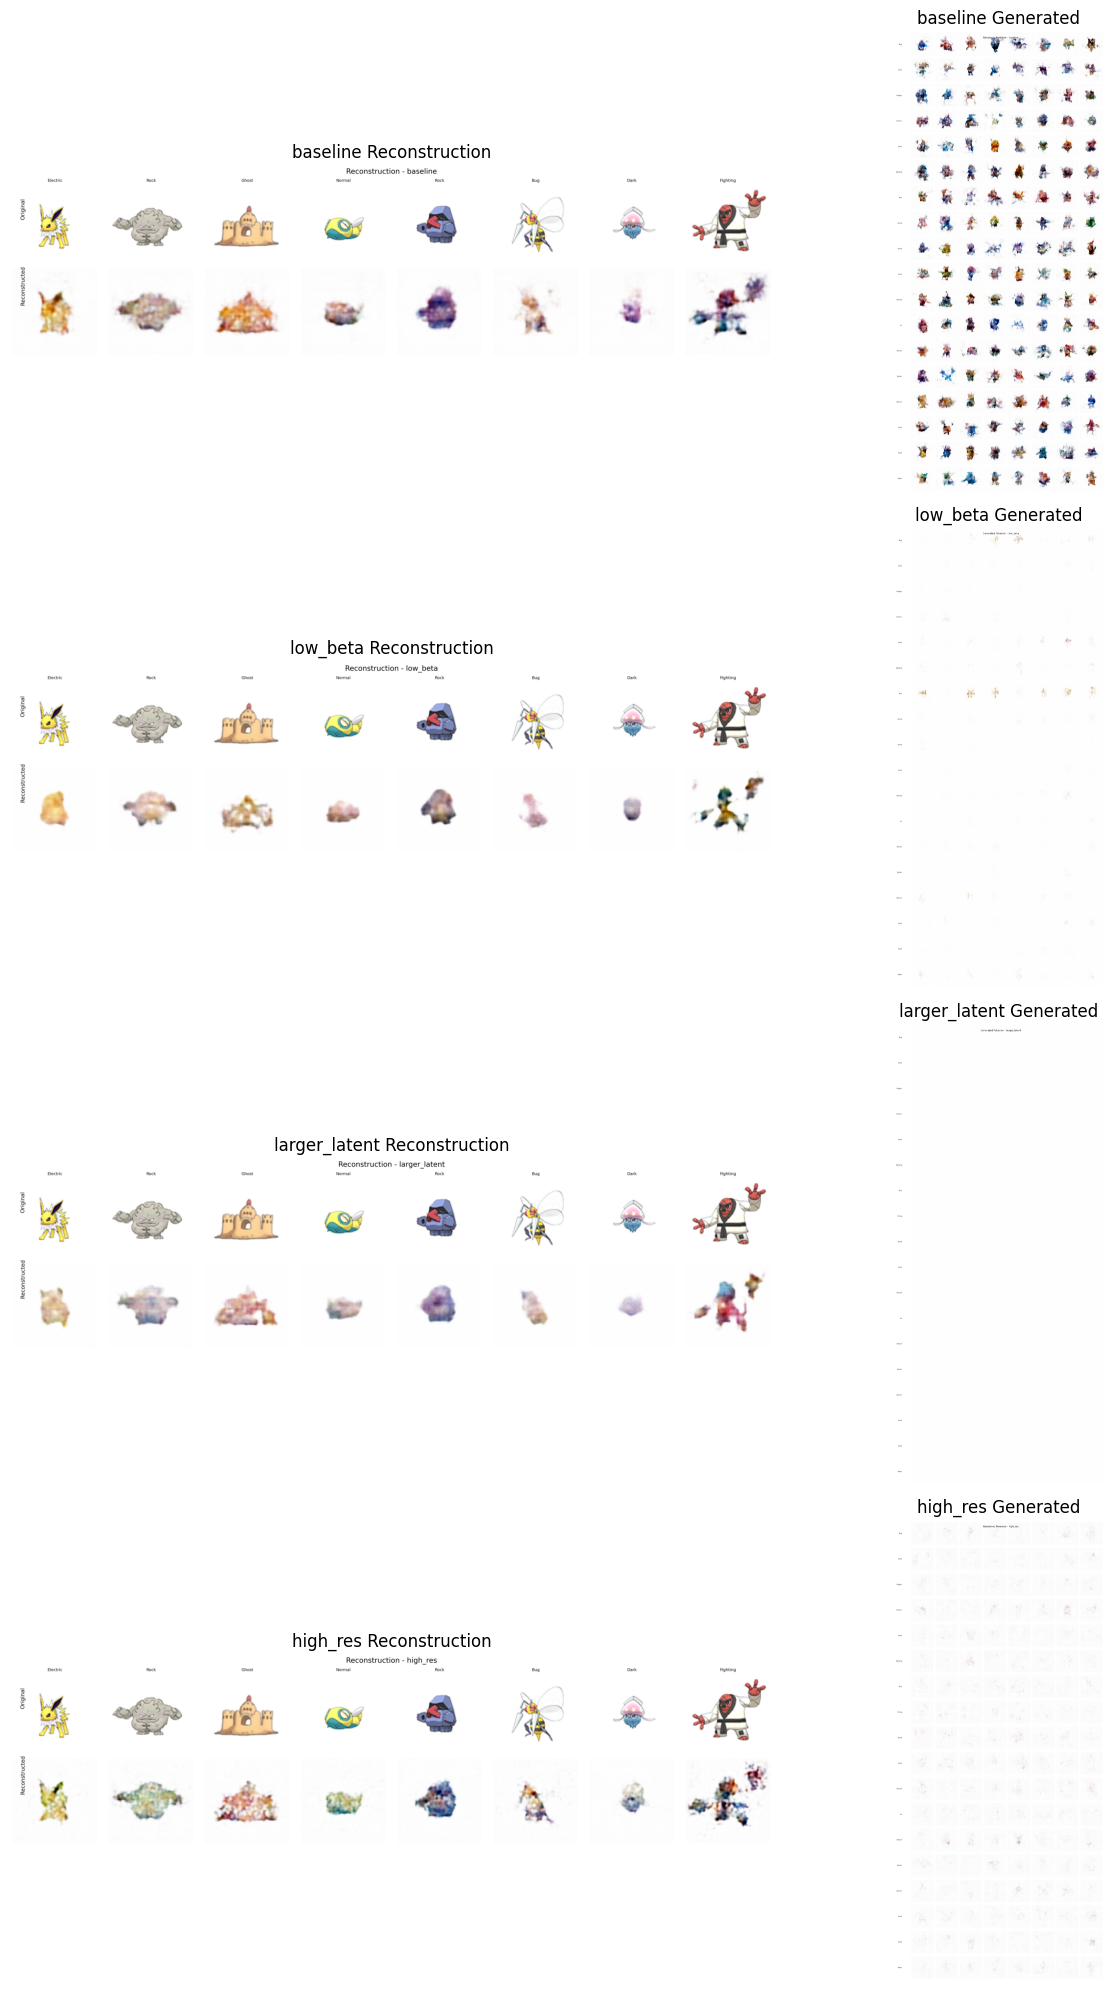

In [ ]:
fig, axes = plt.subplots(
    len(all_results),
    2,
    figsize=(14, 5 * len(all_results))
)

if len(all_results) == 1:
    axes = [axes]

for i, result in enumerate(all_results):

    recon_img = Image.open(
        result["reconstruction_image"]
    )

    gen_img = Image.open(
        result["generated_image"]
    )

    axes[i][0].imshow(recon_img)
    axes[i][0].set_title(
        f"{result['name']} Reconstruction"
    )
    axes[i][0].axis("off")

    axes[i][1].imshow(gen_img)
    axes[i][1].set_title(
        f"{result['name']} Generated"
    )
    axes[i][1].axis("off")

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    "experiment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from google.colab import files

files.download("experiment_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

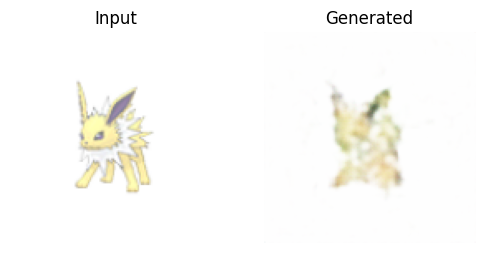

In [ ]:
@torch.no_grad()
def generate_from_input(model, img, type_oh):
    model.eval()

    img = img.unsqueeze(0).to(device)          # [1, 3, 128, 128]
    type_oh = type_oh.unsqueeze(0).to(device)  # [1, NUM_TYPES]

    mu, logvar = model.encode(img, type_oh)

    # use mu for stable reconstruction
    z = mu

    generated = model.decode(z, type_oh)

    return generated[0].cpu()
imgs, types_oh, type_idx = next(iter(val_loader))

input_img = imgs[0]
input_type = types_oh[0]

generated_img = generate_from_input(
    model,
    input_img,
    input_type
)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(((input_img.permute(1,2,0) + 1) / 2).clamp(0,1))
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(((generated_img.permute(1,2,0) + 1) / 2).clamp(0,1))
plt.title("Generated")
plt.axis("off")

plt.show()

In [ ]:
results_df = pd.DataFrame(all_results)

print(results_df.sort_values("best_val"))

            name     best_val  beta  latent_dim loss_type  img_size  \
3       high_res  1321.049967  0.01         256       mse       128   
0       baseline  1540.531820  1.00         128       mse       128   
2  larger_latent  3148.997314  0.10         256        l1       128   
1       low_beta  3286.079346  0.10         128        l1       128   

                                               model  \
3  ConditionalVAE(\n  (encoder): Sequential(\n   ...   
0  ConditionalVAE(\n  (encoder): Sequential(\n   ...   
2  ConditionalVAE(\n  (encoder): Sequential(\n   ...   
1  ConditionalVAE(\n  (encoder): Sequential(\n   ...   

                                             history  \
3  [{'epoch': 1, 'train_loss': 31173.87593410326,...   
0  [{'epoch': 1, 'train_loss': 28680.700662364132...   
2  [{'epoch': 1, 'train_loss': 78138.72724184782,...   
1  [{'epoch': 1, 'train_loss': 31908.771314538044...   

               reconstruction_image              generated_image  
3       high_re

In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    model.eval()
    imgs, types_oh, type_idx = next(iter(loader))
    imgs, types_oh = imgs[:n].to(device), types_oh[:n].to(device)
    recon, _, _ = model(imgs, types_oh)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4.5))
    for i in range(n):
        axes[0, i].imshow(imgs[i].cpu().permute(1, 2, 0))
        axes[0, i].set_title(idx_to_type[type_idx[i].item()], fontsize=9)
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0))
        axes[1, i].axis('off')
    fig.text(0.02, 0.72, 'Original', fontsize=11, rotation=90)
    fig.text(0.02, 0.28, 'Reconstructed', fontsize=11, rotation=90)
    plt.suptitle('Validation Set: Original vs Reconstructed')
    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_reconstructions(model, val_loader)

In [ ]:
@torch.no_grad()
def generate_per_type(model, n_per_type=8):
    model.eval()
    fig, axes = plt.subplots(NUM_TYPES, n_per_type, figsize=(n_per_type*1.4, NUM_TYPES*1.4))
    for ti in range(NUM_TYPES):
        z = torch.randn(n_per_type, LATENT_DIM).to(device)
        c = torch.zeros(n_per_type, NUM_TYPES).to(device); c[:, ti] = 1.0
        samples = model.decode(z, c).cpu()
        for j in range(n_per_type):
            axes[ti, j].imshow(samples[j].permute(1, 2, 0))
            axes[ti, j].axis('off')
        axes[ti, 0].text(-0.4, 0.5, idx_to_type[ti], fontsize=10,
                         transform=axes[ti, 0].transAxes, ha='right', va='center')
    plt.suptitle('Generated Pokemon by Type', fontsize=14)
    plt.tight_layout()
    plt.savefig('samples_per_type.png', dpi=150, bbox_inches='tight')
    plt.show()

generate_per_type(model)